# Error Analysis: Identify characteristics of misclassified sentences

- For the sentences that were incorrectly classified, what are the characteristics in them?
- For the ones that are classified as a prediction, do our prediction properties exist?

In [1]:
import os
import sys

import pandas as pd

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from metrics import EvaluationMetric
from data_processing import DataProcessing

In [2]:
# pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', 40)
# pd.set_option('display.max_rows', None)

## Load Data

In [3]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
combine_data_path = os.path.join(base_data_path, 'classification_results/combined-full_synthetic-v1_2026-03-07/seed40/inference')

In [4]:
model_results_path = os.path.join(combine_data_path, 'inference_chronicle2050_2026-03-07_21-51-47.csv')
# model_results_path = os.path.join(combine_data_path, 'inference_financial_phrasebank-imbalanced_2026-03-07_21-52-34.csv')

model_results_df = DataProcessing.load_from_file(model_results_path, 'csv', sep=',')
model_results_df.head(3)

,index,sentence,label,sentence Embedding,decision_tree_classifier,gradient_boosting_classifier,logistic_regression,perceptron,random_forest_classifier,ridge_classifier,sgd_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier,Dataset
0,0,"By January 1st, 2037, Tesla will have been the...",1,[-4.69374172e-02 1.84888348e-01 -1.93335768e-...,1,1,1,1,1,1,1,1,1,chronicle2050
1,1,An annual average temperature anomaly value ab...,1,[-8.03273544e-02 1.84596255e-01 9.70091950e-...,0,1,1,1,1,1,1,1,0,chronicle2050
2,2,Private Nonfarm business productivity growth w...,1,[-9.73114073e-02 2.70783365e-01 2.02017017e-...,0,0,0,0,0,0,0,0,0,chronicle2050


In [5]:
dataset = 'chronicle2050'
if dataset == 'chronicle2050':
    model_results_df.rename(columns={'sentence':'Base Sentence', 'label':'Sentence Label', 'sentence Embedding':'Base Sentence Embedding'}, inplace=True)
    compare_y_vs_yhat_df = DataProcessing.drop_df_columns(model_results_df, ['index', "Base Sentence Embedding", "Dataset"])
    model_col_names = compare_y_vs_yhat_df.columns.to_list()[2:12]
    print(model_col_names)
elif dataset == 'fpb':
    model_col_names = model_results_df.columns.to_list()[5:14]
    cols_to_drop = ["maya_label", "Author Type", "Base Sentence Embedding", "Dataset"]
    compare_y_vs_yhat_df = DataProcessing.drop_df_columns(model_results_df, cols_to_drop)

compare_y_vs_yhat_df

['decision_tree_classifier', 'gradient_boosting_classifier', 'logistic_regression', 'perceptron', 'random_forest_classifier', 'ridge_classifier', 'sgd_classifier', 'support_vector_machine_classifier', 'x_gradient_boosting_classifier']


,Base Sentence,Sentence Label,decision_tree_classifier,gradient_boosting_classifier,logistic_regression,perceptron,random_forest_classifier,ridge_classifier,sgd_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,"By January 1st, 2037, Tesla will have been the...",1,1,1,1,1,1,1,1,1,1
1,An annual average temperature anomaly value ab...,1,0,1,1,1,1,1,1,1,0
2,Private Nonfarm business productivity growth w...,1,0,0,0,0,0,0,0,0,0
3,No Republican will be President of the USA bef...,1,0,1,1,1,1,1,1,1,1
4,The market capitalization of Berkshire Hathawa...,1,0,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
6397,Many major technology players are [TeleNav Inc...,0,1,0,0,0,0,0,0,0,0
6398,"WaterIQ Technologies, the leader in next-gener...",0,0,1,0,1,0,1,0,1,1
6399,The Business Research Company's 'Clean Coal Te...,0,0,1,1,1,1,1,1,1,1
6400,'Prophecy Market Insights offers a 20% discoun...,0,1,1,1,1,1,1,1,1,1


In [6]:
majority_vote = compare_y_vs_yhat_df.loc[:, model_col_names].mode(axis=1)
print(majority_vote)
compare_y_vs_yhat_df['Majority Vote'] = majority_vote
compare_y_vs_yhat_df

      0
0     1
1     1
2     0
3     1
4     1
...  ..
6397  0
6398  1
6399  1
6400  1
6401  0

[6402 rows x 1 columns]


,Base Sentence,Sentence Label,decision_tree_classifier,gradient_boosting_classifier,logistic_regression,perceptron,random_forest_classifier,ridge_classifier,sgd_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier,Majority Vote
0,"By January 1st, 2037, Tesla will have been the...",1,1,1,1,1,1,1,1,1,1,1
1,An annual average temperature anomaly value ab...,1,0,1,1,1,1,1,1,1,0,1
2,Private Nonfarm business productivity growth w...,1,0,0,0,0,0,0,0,0,0,0
3,No Republican will be President of the USA bef...,1,0,1,1,1,1,1,1,1,1,1
4,The market capitalization of Berkshire Hathawa...,1,0,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6397,Many major technology players are [TeleNav Inc...,0,1,0,0,0,0,0,0,0,0,0
6398,"WaterIQ Technologies, the leader in next-gener...",0,0,1,0,1,0,1,0,1,1,1
6399,The Business Research Company's 'Clean Coal Te...,0,0,1,1,1,1,1,1,1,1,1
6400,'Prophecy Market Insights offers a 20% discoun...,0,1,1,1,1,1,1,1,1,1,1


In [7]:
collect_stats = {}

## Human

In [8]:
human = compare_y_vs_yhat_df['Sentence Label'] == 1
human_predictions_df = compare_y_vs_yhat_df[human]
collect_stats['human_labelled_predictions'] = len(human_predictions_df)
human_predictions_df

,Base Sentence,Sentence Label,decision_tree_classifier,gradient_boosting_classifier,logistic_regression,perceptron,random_forest_classifier,ridge_classifier,sgd_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier,Majority Vote
0,"By January 1st, 2037, Tesla will have been the...",1,1,1,1,1,1,1,1,1,1,1
1,An annual average temperature anomaly value ab...,1,0,1,1,1,1,1,1,1,0,1
2,Private Nonfarm business productivity growth w...,1,0,0,0,0,0,0,0,0,0,0
3,No Republican will be President of the USA bef...,1,0,1,1,1,1,1,1,1,1,1
4,The market capitalization of Berkshire Hathawa...,1,0,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3896,An auto manufacturing plant in Huntsville has ...,1,0,1,1,1,0,1,1,1,1,1
3897,"Wednesday, Toyota Alabama announced it will be...",1,1,0,1,0,0,1,1,1,0,1
3898,Toyota rethinks its EV strategy for the future.,1,1,1,1,1,0,1,1,1,1,1
3899,"The new CEO, Koji Sato, has a big interest in ...",1,0,0,0,0,0,1,0,0,0,0


## Majority Vote

In [9]:
mv = compare_y_vs_yhat_df['Majority Vote'] == 1
mv_predictions_df = compare_y_vs_yhat_df[mv]
collect_stats['majority_vote_models_labelled_predictions'] = len(mv_predictions_df)
mv_predictions_df

,Base Sentence,Sentence Label,decision_tree_classifier,gradient_boosting_classifier,logistic_regression,perceptron,random_forest_classifier,ridge_classifier,sgd_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier,Majority Vote
0,"By January 1st, 2037, Tesla will have been the...",1,1,1,1,1,1,1,1,1,1,1
1,An annual average temperature anomaly value ab...,1,0,1,1,1,1,1,1,1,0,1
3,No Republican will be President of the USA bef...,1,0,1,1,1,1,1,1,1,1,1
4,The market capitalization of Berkshire Hathawa...,1,0,1,1,1,1,1,1,1,1,1
5,A bitcoin will be worth less than $1000US by t...,1,0,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6391,Kioxia and WD utilize advanced scaling and waf...,0,1,1,1,1,1,1,0,1,1,1
6392,The study also contains a compilation of quali...,0,1,1,0,1,0,1,1,1,1,1
6398,"WaterIQ Technologies, the leader in next-gener...",0,0,1,0,1,0,1,0,1,1,1
6399,The Business Research Company's 'Clean Coal Te...,0,0,1,1,1,1,1,1,1,1,1


## Both: Human + Majority Vote

In [10]:
filt_predictions = (compare_y_vs_yhat_df['Sentence Label'] == 1) & (compare_y_vs_yhat_df['Majority Vote'] == 1)
predictions_df = compare_y_vs_yhat_df[filt_predictions]
collect_stats['human_models_agreement_predictions'] = len(predictions_df)
predictions_df

,Base Sentence,Sentence Label,decision_tree_classifier,gradient_boosting_classifier,logistic_regression,perceptron,random_forest_classifier,ridge_classifier,sgd_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier,Majority Vote
0,"By January 1st, 2037, Tesla will have been the...",1,1,1,1,1,1,1,1,1,1,1
1,An annual average temperature anomaly value ab...,1,0,1,1,1,1,1,1,1,0,1
3,No Republican will be President of the USA bef...,1,0,1,1,1,1,1,1,1,1,1
4,The market capitalization of Berkshire Hathawa...,1,0,1,1,1,1,1,1,1,1,1
5,A bitcoin will be worth less than $1000US by t...,1,0,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3895,Motorists can avail of a free 21-point Vehicle...,1,0,1,0,1,0,1,1,1,0,1
3896,An auto manufacturing plant in Huntsville has ...,1,0,1,1,1,0,1,1,1,1,1
3897,"Wednesday, Toyota Alabama announced it will be...",1,1,0,1,0,0,1,1,1,0,1
3898,Toyota rethinks its EV strategy for the future.,1,1,1,1,1,0,1,1,1,1,1


In [11]:
predictions_df['Sentence Label'].value_counts(), predictions_df['Majority Vote'].value_counts()

(Sentence Label
 1    2620
 Name: count, dtype: int64,
 Majority Vote
 1    2620
 Name: count, dtype: int64)

In [12]:
predictions_across_classifiers_df = pd.DataFrame([collect_stats])
predictions_across_classifiers_df

,human_labelled_predictions,majority_vote_models_labelled_predictions,human_models_agreement_predictions
0,3201,3883,2620


In [13]:
for model_col_name in model_col_names:
    filt_model_predictions = (model_results_df[model_col_name] == 1)
    model_predictions = model_results_df[filt_model_predictions]
    collect_stats[model_col_name] = len(model_predictions)

In [14]:
predictions_across_classifiers_df = pd.DataFrame([collect_stats])
predictions_across_classifiers_df

,human_labelled_predictions,majority_vote_models_labelled_predictions,human_models_agreement_predictions,decision_tree_classifier,gradient_boosting_classifier,logistic_regression,perceptron,random_forest_classifier,ridge_classifier,sgd_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,3201,3883,2620,3310,3852,4067,3907,2583,4104,3764,4035,3637


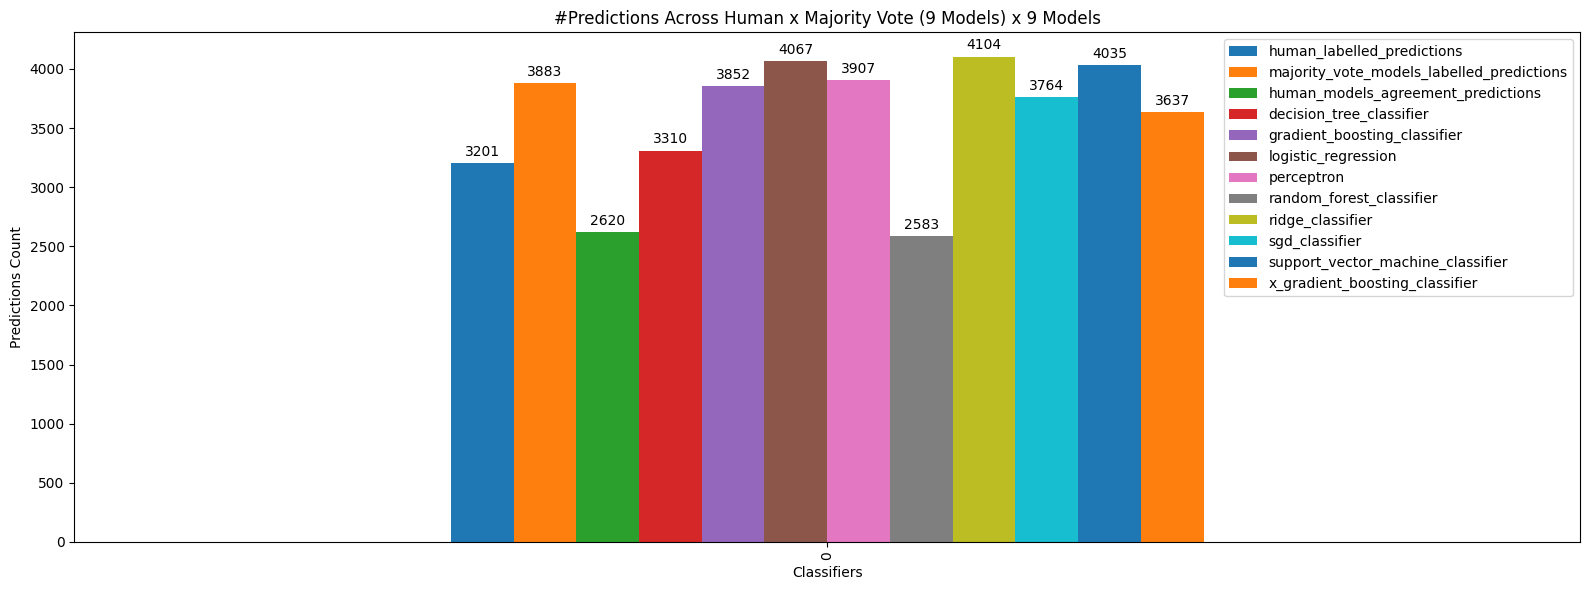

In [15]:
import matplotlib.pyplot as plt

ax = predictions_across_classifiers_df.plot.bar(figsize=(16, 6))

ax.set_xlabel("Classifiers")
ax.set_ylabel("Predictions Count")
ax.set_title("#Predictions Across Human x Majority Vote (9 Models) x 9 Models")

# Add value labels at the top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

plt.tight_layout()
plt.show()

In [16]:
def evaluate_models(
    model_results_df,
    save_path,
    train_val_metrics_dict
):
    """
    Evaluate all model predictions and save unified metrics.
    
    Parameters
    ----------
    y_test_df : pd.DataFrame
        True test labels
    label_name : str
        Name of label column
    save_path : str
        Directory path to save visualizations
    train_val_metrics_dict : dict
        {model_name: {'train_accuracy': float, 'val_accuracy': float}}
    
    Returns
    -------
    tuple
        (eval_reports_df, confusion_matrices, auc_scores)
    """
    print("\n" + "="*50)
    print("EVALUATION RESULTS")
    print("="*50)
    
    get_metrics = EvaluationMetric()
    actual_labels = model_results_df['Sentence Label'].values
    
    eval_reports = {}
    confusion_matrices = {}
    auc_scores = {}
    metrics_summary = []
    
    for model_name in model_col_names:
        predictions = model_results_df[model_name].values
        print(f"### Model: {model_name} ###")
        print(f"\t Predictions: {predictions}")

        
        # Classification report
        eval_report = get_metrics.eval_classification_report(actual_labels, predictions)
        eval_reports[f"{model_name}"] = eval_report
        
        # Confusion matrix
        confusion_mat = get_metrics.get_confusion_matrix(actual_labels, predictions)
        confusion_matrices[model_name] = confusion_mat
        print(f"Confusion Matrix:\n{confusion_mat}\n")
        
        # AUC score
        auc_score = get_metrics.get_auc(actual_labels, predictions)
        auc_scores[model_name] = auc_score
        print(f"AUC Score: {auc_score:.4f}\n")

        # Build unified metrics row
        metrics_row = {
            'model': model_name,
            'test_accuracy': eval_report.get('accuracy', None),
            'precision_class_0': eval_report.get('0', {}).get('precision', None),
            'precision_class_1': eval_report.get('1', {}).get('precision', None),
            'recall_class_0': eval_report.get('0', {}).get('recall', None),
            'recall_class_1': eval_report.get('1', {}).get('recall', None),
            'f1_class_0': eval_report.get('0', {}).get('f1-score', None),
            'f1_class_1': eval_report.get('1', {}).get('f1-score', None),
            'auc': auc_score
        }
        metrics_summary.append(metrics_row)
        
        # Save confusion matrix visualization
        # DataPlotting.visualize_confusion_matrix(
        #     confusion_mat, 
        #     model_name, 
        #     save_path, 
        #     include_version=False
        # )
        # print(f"✓ Saved confusion matrix: confusion_matrix_{model_name}.png\n")
    
    eval_reports_df = pd.DataFrame(eval_reports)
    
    # Save unified metrics summary
    metrics_summary_df = pd.DataFrame(metrics_summary)
    # metrics_file = os.path.join(save_path, 'metrics_summary.csv')
    # metrics_summary_df.to_csv(metrics_file, index=False)
    # print(f"✓ Saved metrics summary to: {metrics_file}")
    
    print("\n" + "="*50)
    print("METRICS SUMMARY (LaTeX)")
    print("="*50)
    print(eval_reports_df.to_latex())
    print()
    
    return eval_reports_df, confusion_matrices, auc_scores, metrics_summary_df

In [17]:
eval_reports_df, confusion_matrices, auc_scores, metrics_summary_df = evaluate_models(model_results_df, '.', '.')


EVALUATION RESULTS
### Model: decision_tree_classifier ###
	 Predictions: [1 0 0 ... 0 1 0]
              precision    recall  f1-score   support

           0       0.57      0.55      0.56      3201
           1       0.57      0.59      0.58      3201

    accuracy                           0.57      6402
   macro avg       0.57      0.57      0.57      6402
weighted avg       0.57      0.57      0.57      6402

Confusion Matrix:
[[1766 1435]
 [1326 1875]]

AUC Score: 0.5687

### Model: gradient_boosting_classifier ###
	 Predictions: [1 1 0 ... 1 1 0]
              precision    recall  f1-score   support

           0       0.77      0.61      0.68      3201
           1       0.68      0.82      0.74      3201

    accuracy                           0.71      6402
   macro avg       0.72      0.71      0.71      6402
weighted avg       0.72      0.71      0.71      6402

Confusion Matrix:
[[1959 1242]
 [ 591 2610]]

AUC Score: 0.7137

### Model: logistic_regression ###
	 Predictio

In [18]:
eval_reports_df

,decision_tree_classifier,gradient_boosting_classifier,logistic_regression,perceptron,random_forest_classifier,ridge_classifier,sgd_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,"{'precision': 0.5711513583441138, 'recall': 0....","{'precision': 0.768235294117647, 'recall': 0.6...","{'precision': 0.7794432548179872, 'recall': 0....","{'precision': 0.7555110220440882, 'recall': 0....","{'precision': 0.6488609583660644, 'recall': 0....","{'precision': 0.783289817232376, 'recall': 0.5...","{'precision': 0.7539802880970432, 'recall': 0....","{'precision': 0.7866497676383608, 'recall': 0....","{'precision': 0.7493670886075949, 'recall': 0...."
1,"{'precision': 0.5664652567975831, 'recall': 0....","{'precision': 0.677570093457944, 'recall': 0.8...","{'precision': 0.660437669043521, 'recall': 0.8...","{'precision': 0.6631686716150499, 'recall': 0....","{'precision': 0.7200929152148664, 'recall': 0....","{'precision': 0.658625730994152, 'recall': 0.8...","{'precision': 0.6780021253985122, 'recall': 0....","{'precision': 0.6681536555142503, 'recall': 0....","{'precision': 0.6895793236183668, 'recall': 0...."
accuracy,0.568729,0.713683,0.703843,0.699157,0.677601,0.703374,0.70931,0.711965,0.715401
macro avg,"{'precision': 0.5688083075708484, 'recall': 0....","{'precision': 0.7229026937877955, 'recall': 0....","{'precision': 0.7199404619307541, 'recall': 0....","{'precision': 0.7093398468295691, 'recall': 0....","{'precision': 0.6844769367904654, 'recall': 0....","{'precision': 0.720957774113264, 'recall': 0.7...","{'precision': 0.7159912067477777, 'recall': 0....","{'precision': 0.7274017115763056, 'recall': 0....","{'precision': 0.7194732061129809, 'recall': 0...."
weighted avg,"{'precision': 0.5688083075708484, 'recall': 0....","{'precision': 0.7229026937877955, 'recall': 0....","{'precision': 0.719940461930754, 'recall': 0.7...","{'precision': 0.709339846829569, 'recall': 0.6...","{'precision': 0.6844769367904654, 'recall': 0....","{'precision': 0.7209577741132639, 'recall': 0....","{'precision': 0.7159912067477778, 'recall': 0....","{'precision': 0.7274017115763055, 'recall': 0....","{'precision': 0.7194732061129808, 'recall': 0...."


In [19]:
auc_scores

{'decision_tree_classifier': np.float64(0.5687285223367697),
 'gradient_boosting_classifier': np.float64(0.7136832239925023),
 'logistic_regression': np.float64(0.703842549203374),
 'perceptron': np.float64(0.6991565135895033),
 'random_forest_classifier': np.float64(0.6776007497656983),
 'ridge_classifier': np.float64(0.7033739456419869),
 'sgd_classifier': np.float64(0.7093095907528897),
 'support_vector_machine_classifier': np.float64(0.7119650109340832),
 'x_gradient_boosting_classifier': np.float64(0.7154014370509215)}

In [20]:
auc_scores

{'decision_tree_classifier': np.float64(0.5687285223367697),
 'gradient_boosting_classifier': np.float64(0.7136832239925023),
 'logistic_regression': np.float64(0.703842549203374),
 'perceptron': np.float64(0.6991565135895033),
 'random_forest_classifier': np.float64(0.6776007497656983),
 'ridge_classifier': np.float64(0.7033739456419869),
 'sgd_classifier': np.float64(0.7093095907528897),
 'support_vector_machine_classifier': np.float64(0.7119650109340832),
 'x_gradient_boosting_classifier': np.float64(0.7154014370509215)}

In [21]:
metrics_summary_df

,model,test_accuracy,precision_class_0,precision_class_1,recall_class_0,recall_class_1,f1_class_0,f1_class_1,auc
0,decision_tree_classifier,0.568729,0.571151,0.566465,0.551703,0.585754,0.561259,0.575948,0.568729
1,gradient_boosting_classifier,0.713683,0.768235,0.677570,0.611996,0.815370,0.681273,0.740111,0.713683
2,logistic_regression,0.703843,0.779443,0.660438,0.568572,0.839113,0.657514,0.739130,0.703843
3,perceptron,0.699157,0.755511,0.663169,0.588878,0.809435,0.661868,0.729038,0.699157
4,random_forest_classifier,0.677601,0.648861,0.720093,0.774133,0.581068,0.705983,0.643154,0.677601
5,ridge_classifier,0.703374,0.783290,0.658626,0.562324,0.844424,0.654664,0.740041,0.703374
6,sgd_classifier,0.709310,0.753980,0.678002,0.621368,0.797251,0.681281,0.732807,0.709310
7,support_vector_machine_classifier,0.711965,0.786650,0.668154,0.581693,0.842237,0.668822,0.745163,0.711965
8,x_gradient_boosting_classifier,0.715401,0.749367,0.689579,0.647298,0.783505,0.694603,0.733548,0.715401
